In [60]:
import pandas as pd
import numpy as np

In [19]:
df=pd.read_excel(r"D:\only dataset\online+retail+ii\online_retail_II.xlsx")

In [20]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [21]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

#  Retail Profit Leakage & Customer Segmentation
## Dataset: Online Retail II (UCI Machine Learning Repository)

### 1. Data Overview & Audit
The dataset consists of real-world transactions for a UK-based retailer. Our initial audit revealed several data quality issues that must be addressed before modeling:

| Column | Description | Initial State (Nulls) |
| :--- | :--- | :--- |
| **Invoice** | Transaction ID. 'C' prefix = Cancellation. | 0 |
| **StockCode** | Unique product ID. | 0 |
| **Description** | Product name. | **2,928** |
| **Quantity** | Units per transaction (Negatives exist). | 0 |
| **InvoiceDate** | Date and Time of sale. | 0 |
| **Price** | Unit price in GBP. | 0 |
| **Customer ID** | Unique Identifier for registered users. | **107,927** |
| **Country** | Customer's country of residence. | 0 |

---

### 2. Business Strategy: The "Is_Guest" Classification
Since we lack a predefined target variable, we are creating one based on a critical business segment: **Guest Shoppers.**

**The Label:**
- **Is_Guest = 1**: Transactions where `Customer ID` is missing.
- **Is_Guest = 0**: Transactions where `Customer ID` is present (Registered Users).

**Why This Matters:**
1. **Conversion Logic**: If a Guest behaves like a high-value loyalist (buying high quantities/high prices), they are our #1 target for account registration marketing.
2. **Operational Efficiency**: Guest transactions often represent different logistics risks. Identifying these patterns helps optimize the shipping pipeline.
3. **Data Valorization**: Instead of deleting 107k "missing" records, we are transforming them into a predictive insight engine.

---

### 3. Data Cleaning Pipeline (Tasks)
1. **Imputation**: Fill `Description` nulls with "MANUAL ENTRY".
2. **Labeling**: Derive `Is_Guest` from null `Customer ID` values.
3. **Financial Cleaning**: Remove `Price <= 0` (removes adjustments/gifts).
4. **Feature Engineering**: 
    - Extract `Hour` from `InvoiceDate`.
    - Calculate `Total_Value` (Quantity * Price).
    - Convert `Quantity` to Absolute Value to handle returns.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [23]:
df['Is_Guest']=df['Customer ID'].isnull().astype(int)

df['Description']=df['Description'].fillna('MANUAL ENTRY')

df['hour']=df['InvoiceDate'].dt.hour

df=df[df['Price']>0]

df['Total_Value']=(df['Quantity']*df['Price']).abs()

C:\Users\mohan\AppData\Local\Temp\ipykernel_32784\798866940.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Total_Value']=(df['Quantity']*df['Price']).abs()


In [24]:
df.nunique()

Invoice        25543
StockCode       4265
Description     4549
Quantity         563
InvoiceDate    23401
Price           1602
Customer ID     4381
Country           40
Is_Guest           2
hour              15
Total_Value     4716
dtype: int64

In [ ]:

order_level = df.groupby('Invoice').agg({
    'Is_Guest': 'max',          # 1 if the whole invoice belongs to a guest
    'Quantity': 'sum',          # Total items in the entire basket
    'Price': 'mean',            # Average price of items in the basket
    'Total_Value': 'sum',       # Total revenue (Magnitude of the order)
    'Country': 'first'  ,       # Keep the country location
    'StockCode':'first'        
}).reset_index()



In [26]:
order_level.nunique()

Invoice        25543
Is_Guest           2
Quantity        1636
Price          15886
Total_Value    17464
Country           40
StockCode       3033
dtype: int64

In [27]:
##Do Guests have "thinner" baskets (fewer items) than Registered users?
order_level.groupby('Is_Guest')['Quantity'].mean()


Is_Guest
0    225.837142
1    149.203779
Name: Quantity, dtype: float64

Although guest buyers purchase with an average quantity of 149, which is lower than loyalists, this figure is still significant. It indicates that guests are not low-value customers by default. Ignoring them risks missing out on customers who demonstrate strong purchase intent and could be nurtured into loyalists.

In [28]:
## how many cancels are there ?

cancelled_orders = df[(df['Quantity'] < 0) & (df['Invoice'].str.startswith('C'))]

print(f"Total cancelled orders: {cancelled_orders['Invoice'].shape}")

Total cancelled orders: (10205,)


Find redflags and guest with a chance of becoming loyalist

In [29]:
# High Diversity = likely loyalist
order_level['Item_Diversity'] = df.groupby('Invoice')['StockCode'].nunique().values

In [30]:
order_level['Item_Diversity'].unique()

array([  8,   4,  19,  23,  17,   2,   7,   1,  27,   9,  15,  26,  13,
        29,  10,  32,  28,  38,  30, 104,  44,  45,  14,  20, 107,  58,
         5,  33,  22,  49,  25,  56,  21,  39,  11,  18,  83,  63,  34,
         6,  46, 501,  50,  79,  31,  37,  41,  16,   3,  24,  42,  12,
        62,  84,  54,  43, 425, 516, 109,  92,  36,  91,  97,  48, 578,
        61,  51,  64,  35,  74,  76, 557,  59,  71,  53,  40,  70,  65,
        47,  69, 114,  66,  85,  82,  73,  75, 545, 507,  60,  57, 153,
       436, 476, 481, 120,  67, 499, 129,  55, 113,  68,  96,  90, 546,
       485, 448, 342, 412, 498, 479,  77,  52,  89, 486, 358,  99, 325,
       170, 316, 279, 103, 133, 100, 199,  94, 101, 173, 181, 158, 320,
       253, 188, 184, 201, 267, 240, 134,  81, 337, 264, 272, 218, 332,
       254, 117,  88, 284, 121, 132, 268, 368, 228, 183, 343, 136, 384,
        72, 363, 340, 110, 152, 151, 168, 108, 166, 164, 174, 163,  98,
        78, 210, 146, 105, 196, 143, 119, 140, 118, 206, 135, 13

In [31]:

red_flags = order_level[
    (order_level['Is_Guest'] == 1) & (
        ((order_level['Quantity'] > 100) & (order_level['Item_Diversity'] < 5)) | 
        (order_level['Quantity'] < 0)
    )
]

print(red_flags)

       Invoice  Is_Guest  Quantity     Price  Total_Value         Country  \
12521   519390         1       426      6.48      3237.60  United Kingdom   
14100   522935         1       120      2.10       252.00  United Kingdom   
21000  C489859         1        -1     69.57        69.57  United Kingdom   
21001  C489860         1        -1      8.50         8.50  United Kingdom   
21002  C489881         1       -47      3.40       147.05         Nigeria   
...        ...       ...       ...       ...          ...             ...   
25480  C537630         1        -1  13541.33     13541.33  United Kingdom   
25481  C537644         1        -1  13474.79     13474.79  United Kingdom   
25482  C537647         1        -1   5519.25      5519.25  United Kingdom   
25483  C537651         1        -1  13541.33     13541.33  United Kingdom   
25484  C537652         1        -1   6706.71      6706.71  United Kingdom   

       StockCode  Item_Diversity  
12521      47566               3  
14100

In [32]:
def identify_guest_type(row):
    if row['Is_Guest'] == 0:
        return 'Registered User'
    if row['Quantity'] < 0:
        return 'Guest Return (Risk)'
    if row['Quantity'] > 100 and row['Item_Diversity'] < 5:
        return 'Bulk Guest (Red Flag)'
    if row['Quantity'] > 100 and row['Item_Diversity'] > 20:
        return 'Potential VIP Loyalist'
    return 'Standard Guest'

order_level['Guest_Category'] = order_level.apply(identify_guest_type, axis=1)


print(order_level['Guest_Category'].value_counts())

Guest_Category
Registered User           23585
Standard Guest             1266
Potential VIP Loyalist      471
Guest Return (Risk)         219
Bulk Guest (Red Flag)         2
Name: count, dtype: int64


### Potential VIPs
- We have 471 guests who buy big but are still anonymous  
- That’s revenue we’re missing out on because they haven’t been converted into loyal customers  

### Bulk Red Flags
- Only 2 cases flagged as bulk buying issues  
- Good sign — most guest traffic looks genuine  

### Guest Returns
- 219 returns came from guests  
- Since they don’t have IDs, these are harder for customer service to manage  

In [33]:
# Calculate Total Revenue per Segment
segment_value = order_level.groupby('Guest_Category')['Total_Value'].agg(['sum', 'mean', 'count'])
segment_value['contribution_pct'] = (segment_value['sum'] / segment_value['sum'].sum()) * 100

print("\nSegment Contribution to Total Revenue:")
print(segment_value.sort_values(by='sum', ascending=False))


Segment Contribution to Total Revenue:
                                sum         mean  count  contribution_pct
Guest_Category                                                           
Registered User         9315797.974   394.988254  23585         85.180841
Potential VIP Loyalist  1160133.340  2463.128110    471         10.607909
Standard Guest           310639.380   245.370758   1266          2.840393
Guest Return (Risk)      146434.240   668.649498    219          1.338950
Bulk Guest (Red Flag)      3489.600  1744.800000      2          0.031908


### Potential VIP Loyalists
- They contribute about **10% of total revenue**  
- But they make up only  around **0.5% of all customers**  
- This shows they are extremely valuable and should be targeted for retention and loyalty programs  

### Bulk Guests (Red Flags)
- Their contribution to revenue is very small (<1%)  
- Even though the impact is low right now, their unusual buying patterns could pose risks  
- Best to keep monitoring this segment closely  

In [ ]:
## customer tenure (Average time between purchases)
#  Diversity Score (Unique Items / Total Items)
# High diversity often means a 'Real' shopper; Low diversity means a 'Reseller'

df_sorted = df.sort_values(['Customer ID', 'InvoiceDate'])
df_sorted['Days_Between'] = df_sorted.groupby('Customer ID')['InvoiceDate'].diff().dt.days
avg_gap = df_sorted.groupby('Customer ID')['Days_Between'].mean().fillna(-1) 

diversity = df.groupby('Customer ID').agg({
    'StockCode': 'nunique',
    'Quantity': 'sum'
})
diversity['Diversity_Index'] = diversity['StockCode'] / diversity['Quantity']

In [37]:
diversity

,StockCode,Quantity,Diversity_Index
Customer ID,,,
12346.0,29,52,0.557692
12347.0,70,828,0.084541
12348.0,20,373,0.053619
12349.0,92,988,0.093117
12351.0,21,261,0.080460
...,...,...,...
18283.0,158,336,0.470238
18284.0,28,493,0.056795
18285.0,12,145,0.082759


In [ ]:
## model to identify VIP customers among registered users (Is_Guest=0) based on their behavior (frequency, diversity, monetary value


train_df = df[df['Is_Guest'] == 0].groupby('Customer ID').agg({
    'Invoice': 'nunique',      # Frequency
    'StockCode': 'nunique',    # Diversity
    'Total_Value': 'sum'   ,    # Monetary Value
    'Quantity': 'sum'
})


threshold = train_df['Total_Value'].quantile(0.80)## considering top 20% spenders as VIPs
y = (train_df['Total_Value'] >= threshold).astype(int)## boolean to int (1 for VIP, 0 for non-VIP)


X = train_df[['Invoice', 'StockCode', 'Quantity']] # We only want the model to learn from behavior
                            ## Exclude Total_Value to prevent data leakage since it's directly used to define VIPs
print(f"Total Customers for Training: {len(X)}")
print(f"Total VIPs identified: {y.sum()}")

Total Customers for Training: 4381
Total VIPs identified: 877


In [54]:
X

,Invoice,StockCode,Quantity
Customer ID,,,
12346.0,15,29,52
12347.0,2,70,828
12348.0,1,20,373
12349.0,4,92,988
12351.0,1,21,261
...,...,...,...
18283.0,6,158,336
18284.0,2,28,493
18285.0,1,12,145


In [52]:
y

Customer ID
12346.0    0
12347.0    0
12348.0    0
12349.0    1
12351.0    0
          ..
18283.0    0
18284.0    0
18285.0    0
18286.0    0
18287.0    1
Name: Total_Value, Length: 4381, dtype: int64

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
import matplotlib.pyplot as plt

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
print(f"Model Accuracy: {model.score(X_test, y_test):.2f}")
print(f"Classification Report:\n{classification_report(y_test, model.predict(X_test))}")
print(f"Feature Importances:\n{pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)}")
print()

Model Accuracy: 0.94
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       708
           1       0.86      0.82      0.84       169

    accuracy                           0.94       877
   macro avg       0.91      0.89      0.90       877
weighted avg       0.94      0.94      0.94       877

Feature Importances:
Quantity     0.546525
StockCode    0.228635
Invoice      0.224841
dtype: float64


In [63]:
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"AUC-ROC Score: {auc:.2f}")

AUC-ROC Score: 0.97


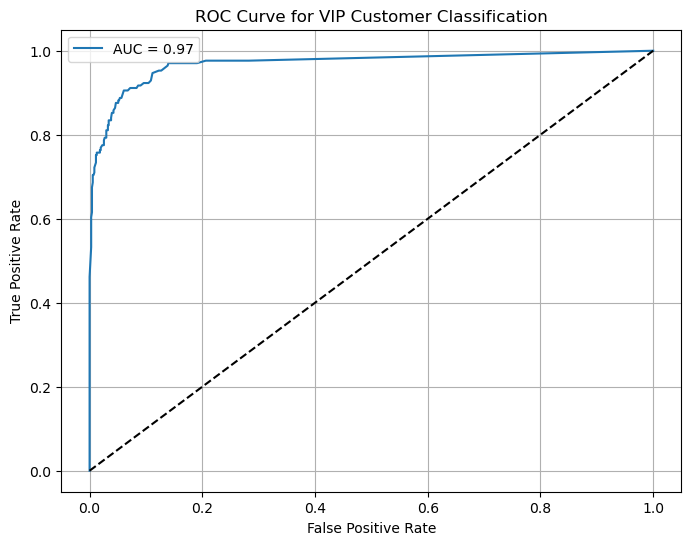

In [64]:
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for VIP Customer Classification')
plt.legend()
plt.grid(True)
plt.show()